# Libraries

In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/deep-learning-az-ann/Churn_Modelling.csv


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping

# Dataset Loading

In [15]:
df = pd.read_csv('/kaggle/input/deep-learning-az-ann/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [16]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [17]:
X = df.iloc[:, 3:13].values #col 1,2 et 3 n'impactent pas la prediction
y = df.iloc[:, 13].values

In [18]:
#geography & gender sont textuelles -> numériques

le1 = LabelEncoder()
X[:, 1] = le1.fit_transform(X[:, 1])
le2 = LabelEncoder()
X[:, 2] = le2.fit_transform(X[:, 2])

# Train,Test and Split

In [22]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,test_size=0.2,random_state=0)

In [23]:
# Scaling 
# features qui n'ont pas la meme echelle
# risque que le modele considère les grandes valeurs balance = 12500 comme importantes par rapport à par exp NumOfProducts = 2 petite

sc = StandardScaler()
xtrain = sc.fit_transform(xtrain)
xtest = sc.transform(xtest) # pas de fit pour que le modele n'apprenne pas les paramètres statistiques du test set

#maintenant toutes les colonnes ont une moyenne = 0 et un écart type = 1

In [37]:
class_weights = compute_class_weight('balanced', classes=np.unique(ytrain), y=ytrain)
class_weights = dict(enumerate(class_weights))

# Artificial Neural Network

In [38]:
clf = Sequential()
clf.add(Dense(16, input_dim=10, activation='relu', kernel_initializer='he_uniform'))
clf.add(Dropout(0.2))  # un peu moins pour garder l'information
clf.add(Dense(12, activation='relu', kernel_initializer='he_uniform'))
clf.add(Dense(8, activation='relu', kernel_initializer='he_uniform'))
clf.add(Dense(1, activation='sigmoid'))
clf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
# Callback pour éviter overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [40]:
# train
model = clf.fit(
    xtrain, ytrain,
    validation_split=0.2,
    epochs=100,
    batch_size=16,  # batch plus petit
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6797 - loss: 0.7717 - val_accuracy: 0.6913 - val_loss: 0.6099
Epoch 2/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6872 - loss: 0.6211 - val_accuracy: 0.7069 - val_loss: 0.5819
Epoch 3/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7011 - loss: 0.6019 - val_accuracy: 0.6894 - val_loss: 0.6040
Epoch 4/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6959 - loss: 0.5798 - val_accuracy: 0.7356 - val_loss: 0.5274
Epoch 5/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7231 - loss: 0.5651 - val_accuracy: 0.7194 - val_loss: 0.5438
Epoch 6/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7403 - loss: 0.5395 - val_accuracy: 0.7300 - val_loss: 0.5342
Epoch 7/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7249 - loss: 0.5507 - val_accuracy: 0.7519 - val_loss: 0.4933
Epoch 8/100
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7332 - loss: 0.5246 - val_accu

# Save Model

In [41]:
clf.save('BankExit.h5')

# Evaluation

In [42]:
threshold = 0.6
y_pred_prob = clf.predict(xtest)
y_pred = (y_pred_prob > threshold).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


# Résultats

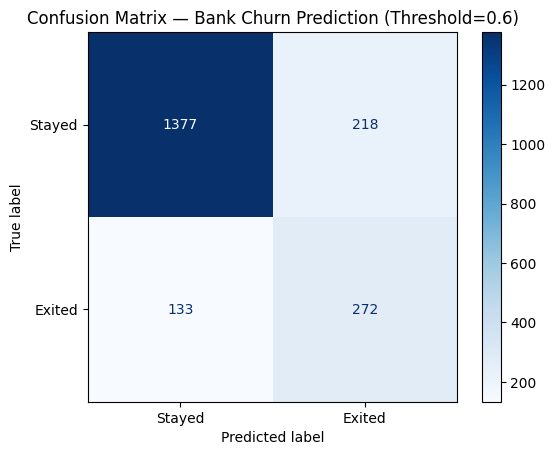

In [43]:
cm = confusion_matrix(ytest, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Exited"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — Bank Churn Prediction (Threshold={threshold})")
plt.show()

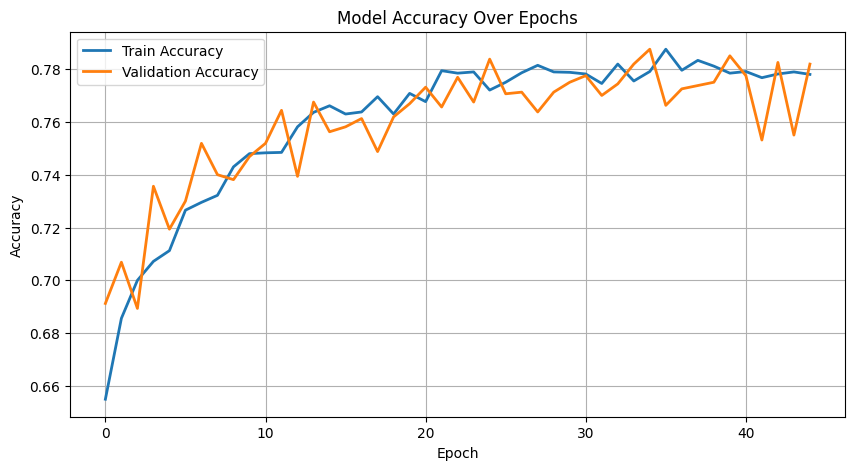

In [45]:
# Visualisation de la précision 
plt.figure(figsize=(10,5))
plt.plot(model.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(model.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

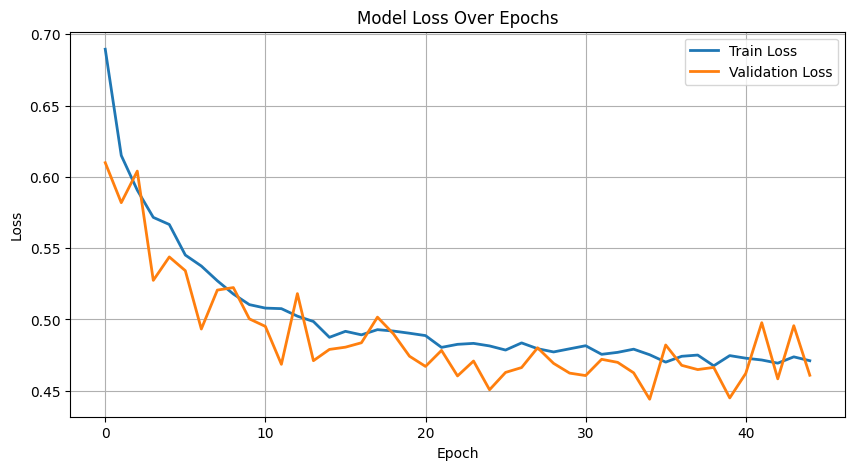

In [46]:
# Visualisation de la perte
plt.figure(figsize=(10,5))
plt.plot(model.history['loss'], label='Train Loss', linewidth=2)
plt.plot(model.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [47]:
example = np.array([[720, 2, 0, 32, 1, 0, 1, 0, 0, 20000]])  # Exemple : client
example = sc.transform(example)
prob = clf.predict(example)[0][0]
print(f"\nProbabilité de quitter la banque : {prob*100:.2f}%")
if prob > threshold:
    print("➡ Le client risque de quitter la banque.")
else:
    print("✅ Le client restera probablement fidèle.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Probabilité de quitter la banque : 53.93%
✅ Le client restera probablement fidèle.
